In [2]:
import torch
x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [7]:
#在我们来计算关于xde 梯度之前我们需要一个地方来存储我们的梯度
x.requires_grad_(True) #等价于x=torch.arange(4.0,requires_grad=True)
x.grad#默认值是None。   #告诉pytorch现在张量以后要对它进行求导，请帮我记住它参与的所有的运算过程

In [9]:
y = 2 * torch.dot(x,x)
y

tensor(28., grad_fn=<MulBackward0>)

In [10]:
y.backward()
x.grad

tensor([ 0.,  4.,  8., 12.])

In [11]:
x.grad == 4* x

tensor([True, True, True, True])

In [15]:
#在默认情况下，pytorch会累积梯度，我们需要清楚之前的值
x.grad.zero_()
y= x.sum()
y.backward()
x.grad


tensor([1., 1., 1., 1.])

In [17]:
#深度学习中，我们的目的不是计算微分，而是批量中每个样本单独计算偏导数只和
#对非标量调用backward需要传入一个gradient参数，该参数指定微分函数
x.grad.zero_()
y = x * x
#等价于.backward(torch.ones(len(x))
y.sum().backward()
x.grad

tensor([0., 2., 4., 6.])

In [18]:
x.grad.zero_()
y = x *x 
u =y.detach()
z=u *x
z.sum().backward()
x.grad==u

tensor([True, True, True, True])

In [19]:
x.grad.zero_()
y.sum().backward()
x.grad==2 * x

tensor([True, True, True, True])

In [23]:
def f(a):
    b =a *2 
    while b.norm() < 1000:
        b =b *2 
        if b.sum() > 0 : 
            c =b
        else :
            c = 100 *b
        return c

a = torch.randn(size=(),requires_grad=True)
d = f(a)
d.backward()

a.grad == d/a           

tensor(True)

In [67]:
#线性回归从零开始实现。   #matplotlib是python里专门用来画图的库 mat = matrix 矩阵 plot制图 lib库  inline在行里
%matplotlib inline 
import random  
#让 matplotlib 画的图直接显示在 notebook 的单元格下方，而不是弹出一个独立窗口。
import torch
#真正的 PyTorch 是上一行的 import torch。两个 torch 名字撞车了，但完全是两个不同的东西——这也是为什么要 as d2l 重命名，否则会覆盖掉真正的 torch。
from d2l import torch as d2l 
#d2l是一个python的包，这个包里有个模块叫torch，是d2l作者自己写的 as d2l是给它起了个简称 后面d2l.就能调用它

#根据一个有噪声的线性模型构造一个人造数据集。 我们使用线性模型参数w=[2，-3.4]转置，b=4.2和噪声项c生成数据集及其标签：
#y=Xw+b+c噪声

In [31]:
def synthetic_data(w,b,num_examples):
    """生成 y = Xw + b + 噪声。 """
    x = torch.normal(0,1,(num_examples,len(w)))
    y = torch.matmul(x,w)+b
    y += torch.normal(0,0.01,y.shape)
    return x,y.reshape((-1,1))

true_w = torch.tensor([2,-3.4])
true_b = 4.2
features,labels = synthetic_data(true_w,true_b,1000)


In [69]:
#features 中的每一行都包含一个二维数组样本， labels中的每一行都包含一维标签值 （一个标量）
print('features:',features[0],'\nlabel:',labels[0])

features: tensor([ 0.4910, -0.0598]) 
label: tensor([5.3941])


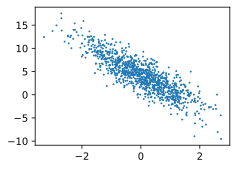

In [34]:
d2l.set_figsize()  #主要用来画散点图，从d2l这个库里调用的
d2l.plt.scatter(features[:,1].detach().numpy(),labels.detach().numpy(),1);   #d2l.plt.scatter这个也是散点图也是从里面调用的

In [43]:
#定义一个data_iter函数，该函数接受批量大小，特征矩阵和标签向量作为输入，生成大小为batch_size的小批量
def data_iter(batch_size,features,labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    #这些样本是随机读取，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples,batch_size):
        batch_indices = torch.tensor(
            indices[i:min(i+batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]

batch_size = 10 
for x,y in data_iter(batch_size,features,labels):
            print(x,'\n',y)
            break
                                                   

tensor([[-0.1646, -0.4259],
        [-0.9630, -0.1800],
        [-1.5560, -0.5890],
        [ 0.3358, -0.5936],
        [ 0.1634,  0.2698],
        [ 2.1154, -0.8460],
        [ 1.3809,  1.5180],
        [-2.1679, -0.8120],
        [-1.5218,  0.3165],
        [-0.2035,  0.2206]]) 
 tensor([[ 5.3258],
        [ 2.8757],
        [ 3.1024],
        [ 6.9030],
        [ 3.6125],
        [11.3075],
        [ 1.8088],
        [ 2.6393],
        [ 0.0566],
        [ 3.0440]])


In [46]:
#上面是定义好了数据
#下面我们要把模型定义好
#定义初始化模型参数
w = torch.normal(0,0.01,size=(2,1),requires_grad = True)
b = torch.zeros(1,requires_grad = True）       #这里的形状是b (1,)不是（1.1）这里就运用了之前学习的广播机制broadcasting


In [48]:
#定义模型
def linreg(X,w,b):  #这里的X，w是假设的，叫模型参数，为什么要定义模型后面训练要不断的调用，更新w,b 预测linreg(X,w,b) 所以模型就是一个预测机器
    """线性回归模型"""     #linear regression的缩写是线性回归 ，linear是线性的，regression是回归的意思
    return torch.matmul(X,w)+b  #它返回的就是矩阵加偏置的结果，返回到了哪里返回到了调用它的地方

In [49]:
#定义损失函数
def squared_loss(y_hat,y):   #loss到底算什么，为什么能告诉w怎么调整？ 模型负责猜答案，loss负责评价猜的有多离谱 loss告诉我们w,b往哪里调整，循环
    """均方损失。"""            #squared_loss :计算模型预测值和真实的标签之间的距离
    return (y_hat - y.reshape(y_hat.shape))**2/2  #这里就是预测值 y_hat - 真实值 y.reshape(y_hat.shape)
    

In [52]:
#定义优化算法
def sgd(params,lr,batch_size):  #定义一个优化器，输入3个params,这里传入[w,b]也就是告诉sgd:你要调整的这两个东西 params=parameter
    """小批量随机梯度下降。"""     #lr=0.03,学习率 
    with torch.no_grad():
        for param in params:
            param -=lr*param.grad/batch_size
            param.grad.zero_() #pytorch里我们默认梯度会累积所以，用完清零
            

In [71]:
#训练过程
lr = 0.03
num_epochs = 3 #把整个数据扫3遍
net = linreg #模型 ，可以换成不一样别的模型。 这里把模型保存下来 network的缩写，以后（X,w,b)就是调用线性模型也就是 \(\hat y=Xw+b\)
loss = squared_loss #loss就是我们均方损失  保存损失函数，就是计算预测错了多少
 
for epoch in range(num_epochs):   #两层for loop。外层循环这里控制训练次数 num_epoch =3就是训练3次
    for X,y in data_iter(batch_size,features,labels):  #内层循环：这个很重要，你之前学习的data_iter是什么，假设你1000个样本，那么data_iter每次拿10个样本
        l = loss(net(X,w,b),y) #'x'和‘y'的小批量损失。#把预测的y和真实的y来做损失 这样子损失就是一个长为批量大小的向量l。l是每个样本的loss
        #因为‘1’形状是（‘batch_size’，1），而不是一个标量。‘1’中的所有元素被加到
        #并以此计算关于[w,b]的梯度
        l.sum().backward() #求和之后算梯度 这里连接你之前学过的autograd 为什么是sum 因为batch里有10个样本，loss可能是[2,3,5,] 自动求偏导loss/偏导w 和偏导loss/偏导b,这一步就是告诉我应该如何调整参数
        sgd([w,b],lr,batch_size) #使用参数梯度更新参数，拿梯度修改w,b 然后进入下一次循环重新预测重新计算loss ,重新调整
    with torch.no_grad():
        train_l = loss(net(features,w,b),labels)
        print(f'epoch {epoch + 1},loss {float(train_l.mean()):f}')

epoch 1,loss 0.000051
epoch 2,loss 0.000051
epoch 3,loss 0.000051


In [62]:
#比较真实参数和通过训练学到的参数来评估训练的成功程度
print(f'w的估计误差:{true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差:{true_b - b }')
#w的估计误差：tensor([0.0004, - 0.0003],grad_fn= <SubBackward0>)
#b的估计误差：tensor([0.0008],grad_fn=<RsubBackward1>)


w的估计误差:tensor([ 0.0008, -0.0005], grad_fn=<SubBackward0>)
b的估计误差:tensor([0.0003], grad_fn=<RsubBackward1>)


In [70]:
print("w 的形状:", w.shape)
print("w 的内容:")
print(w)
print()
print("X 的形状:", features.shape)
print("X 的前5行:")
print(features[:5])

w 的形状: torch.Size([2, 1])
w 的内容:
tensor([[ 1.9992],
        [-3.3995]], requires_grad=True)

X 的形状: torch.Size([1000, 2])
X 的前5行:
tensor([[ 0.4910, -0.0598],
        [-1.1956, -0.8031],
        [ 0.5980, -1.1912],
        [ 0.8648,  0.8854],
        [-0.0046,  0.6165]])
